# improved results for two analysis

## Results follow Analysis part

---
## Analysis part

In [1]:
import descriptive as desc
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA

In [2]:
%%capture
%run machine.ipynb

### PCA for the train/ test data

#### Check how the data looks after PCA

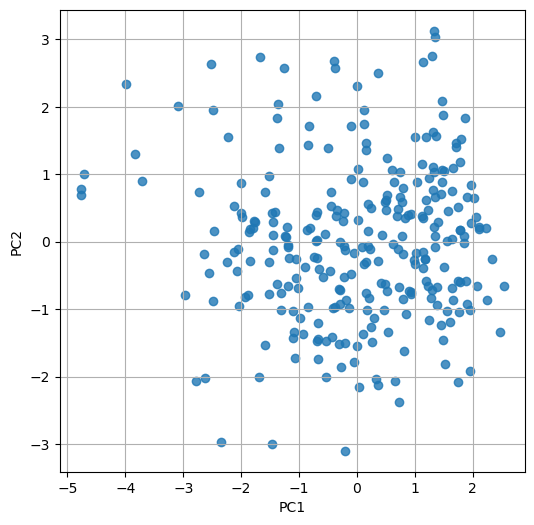

exped_var_ratio: [0.23525653 0.1497248 ]
Cum_con_rate: 0.38498132922529094


,age,Medu,Fedu,travel,study,failures,freetime,go_out,absences
PC1,-0.322379,0.540126,0.511467,-0.317117,0.180788,-0.434440,-0.012603,-0.142396,-0.017781
PC2,0.095915,0.249843,0.259201,-0.015790,-0.380086,0.179134,0.552043,0.602903,0.127068


,age,Medu,Fedu,travel,study,failures,freetime,go_out,absences
PC1,-0.322379,0.540126,0.511467,-0.317117,0.180788,-0.434440,-0.012603,-0.142396,-0.017781
PC2,0.095915,0.249843,0.259201,-0.015790,-0.380086,0.179134,0.552043,0.602903,0.127068


array([0.23525653, 0.1497248 ])

In [3]:

pca = PCA(n_components=2)
pca.fit(desc.xtrain_scaled)
feature_train = pca.transform(desc.xtrain_scaled)
pd.DataFrame(feature_train, columns=["PC1", "PC2"]).head()
plt.figure(figsize=(6, 6))
plt.scatter(feature_train[:, 0], feature_train[:, 1], alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()

print(f"exped_var_ratio: {pca.explained_variance_ratio_}")
print(f"Cum_con_rate: {sum(pca.explained_variance_ratio_)}")
df_components = pd.DataFrame(pca.components_, columns=desc.xtrain_scaled.columns, index=["PC1", "PC2"])
display(df_components)

styled_df = df_components.style.map(desc.color_cells)
display(styled_df)
pca.explained_variance_ratio_

##

In [4]:

pca = PCA(n_components=2)
pca.fit(desc.xtrain_scaled)
feature_train = pca.transform(desc.xtrain_scaled)
df_train_pca = pd.DataFrame(feature_train, columns=["PC1", "PC2"])
feature_test = pca.transform(desc.xtest_scaled)
df_test_pca  = pd.DataFrame(feature_test, columns=["PC1", "PC2"])

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Pass/ Fail Distribution in 2D: PC1 vs PC2 (with test set) (Improved)</span></p><br><br>

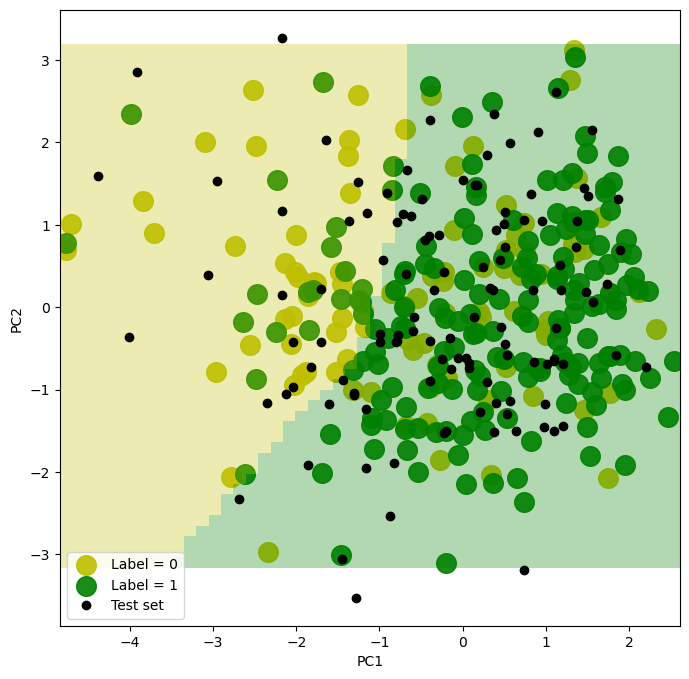

In [5]:

mlp_pca = MLPClassifier(alpha=0.001,
                  hidden_layer_sizes=(50, 20),
                  random_state=0, max_iter=5000)
mlp_pca.fit(df_train_pca, desc.yc_train)

def decition_surface_improved(num=1):
    plt.figure(figsize=(8,8))
    plot_decision_surface(mlp_pca, df_train_pca, desc.y_train_pca, colors = ['y', 'g'])
    plt.plot(df_test_pca.iloc[:,0], df_test_pca.iloc[:,1], 'ko', label='Test set')
    desc.display_title("Pass/ Fail Distribution in 2D: PC1 vs PC2 (with test set) (Improved)", pref='Figure', num=num)
    plt.legend()
    plt.ylabel("PC2")
    plt.xlabel("PC1")
    plt.show()

decition_surface_improved(num=1)

In [6]:
labels_pred_train = mlp_pca.predict(df_train_pca)
labels_pred_test  = mlp_pca.predict(df_test_pca)
cr_train          = accuracy_score(desc.yc_train, labels_pred_train)
cr_test           = accuracy_score(desc.yc_test, labels_pred_test)

print( f'Classification rate (training) = {cr_train}' )
print( f'Classification rate (test)     = {cr_test}' )

print(sum(desc.yc_train)/ len(desc.yc_train))
print(sum(desc.yc_test) / len(desc.yc_test))

Classification rate (training) = 0.717391304347826
Classification rate (test)     = 0.6974789915966386
0.6630434782608695
0.6890756302521008


In [7]:
from sklearn.metrics import confusion_matrix

print("Improved Model Prediction:")
print(confusion_matrix(desc.yc_test, labels_pred_test))
# 予測ラベルの先頭10個を見てみる
print("Predictions:", labels_pred_test[:10])

Improved Model Prediction:
[[11 26]
 [10 72]]
Predictions: [1 1 0 1 1 1 1 1 1 1]


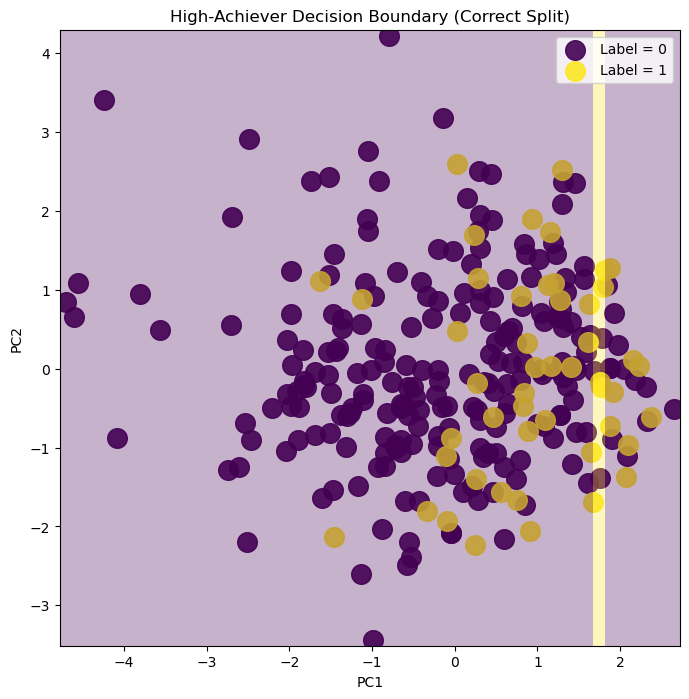

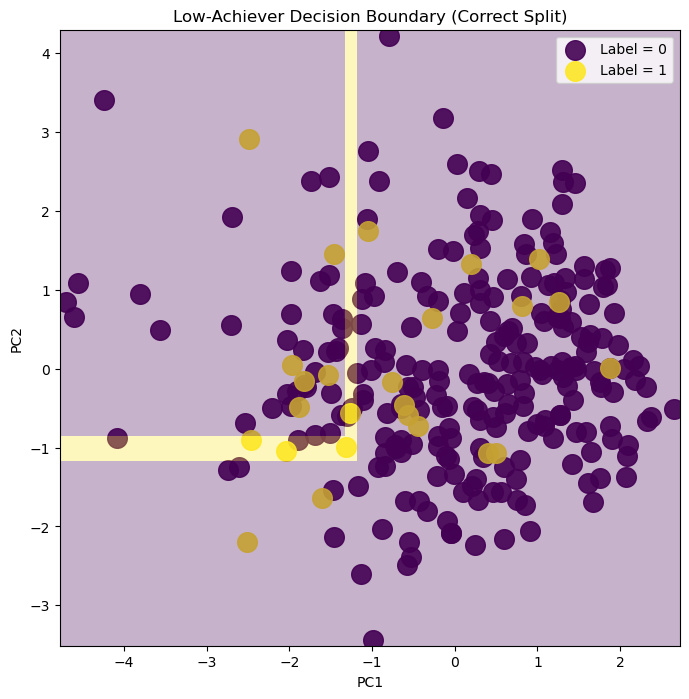

High Model Accuracy: 0.765
Low Model Accuracy: 0.824


In [8]:
from sklearn.tree import DecisionTreeClassifier

pca_hl = PCA(n_components=2)
X_train_hl_pca = pca_hl.fit_transform(desc.X_train_hl_scaled)
X_test_hl_pca  = pca_hl.transform(desc.X_test_hl_scaled)

df_train_hl_pca = pd.DataFrame(X_train_hl_pca, columns=["PC1", "PC2"])
df_test_hl_pca  = pd.DataFrame(X_test_hl_pca, columns=["PC1", "PC2"])

# high
y_train_high = (desc.y_train_h >= 15).astype(int).reset_index(drop=True)
y_test_high  = (desc.y_test_h >= 15).astype(int).reset_index(drop=True)

dt_pca_high = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pca_high.fit(df_train_hl_pca, y_train_high)

plt.figure(figsize=(8,8))
plot_decision_surface(dt_pca_high, df_train_hl_pca, y_train_high)
plt.title("High-Achiever Decision Boundary (Correct Split)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# low
y_train_low = (desc.y_train_l <= 5).astype(int).reset_index(drop=True)
y_test_low  = (desc.y_test_l <= 5).astype(int).reset_index(drop=True)

dt_pca_low = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pca_low.fit(df_train_hl_pca, y_train_low)

plt.figure(figsize=(8,8))
plot_decision_surface(dt_pca_low, df_train_hl_pca, y_train_low)
plt.title("Low-Achiever Decision Boundary (Correct Split)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print(f"High Model Accuracy: {dt_pca_high.score(df_test_hl_pca, y_test_high):.3f}")
print(f"Low Model Accuracy: {dt_pca_low.score(df_test_hl_pca, y_test_low):.3f}")

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Impact calculated via PCA Loadings</span></p><br><br>

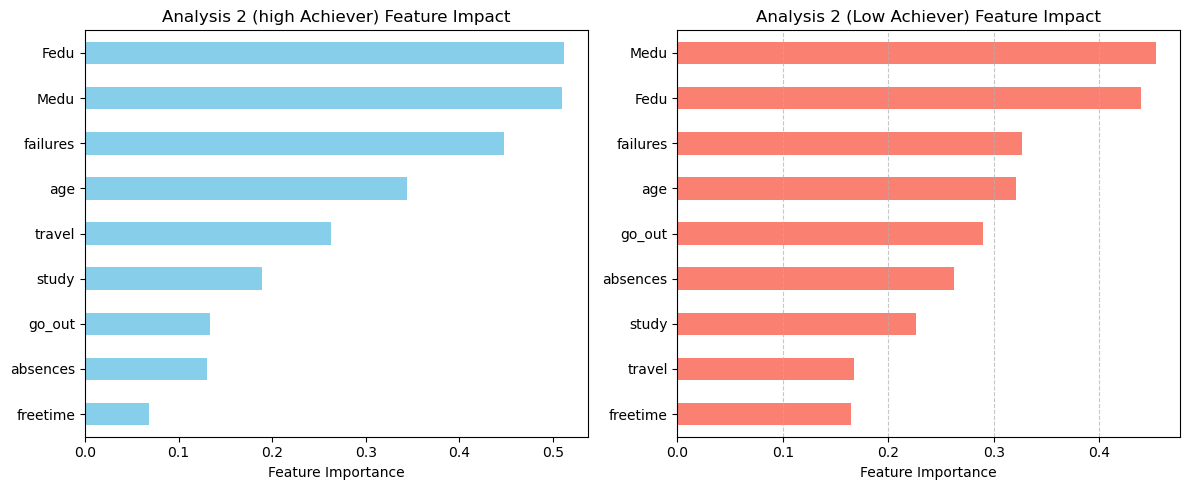

In [13]:
## isn't used
def decision_feature_improved(num=1):
    pc_importance_h = dt_pca_high.feature_importances_
    pc_loadings_h = np.abs(pca_hl.components_)
    restored_importance_h = np.dot(pc_importance_h, pc_loadings_h)
    
    pc_importance_l = dt_pca_low.feature_importances_
    pc_loadings_l = np.abs(pca_hl.components_)
    restored_importance_l = np.dot(pc_importance_l, pc_loadings_l)
    
    s_importance_h = pd.Series(restored_importance_h, index=desc.numeric_vars)
    s_importance_l = pd.Series(restored_importance_l, index=desc.numeric_vars)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    desc.display_title("Impact calculated via PCA Loadings", pref='Figure', num=num)
    
    s_importance_h.sort_values().plot(kind='barh', ax=ax1, color='skyblue')
    ax1.set_title('Analysis 2 (high Achiever) Feature Impact')
    ax1.set_xlabel('Feature Importance')
    s_importance_l.sort_values().plot(kind='barh', ax=ax2, color='salmon')
    ax2.set_title('Analysis 2 (Low Achiever) Feature Impact')
    ax2.set_xlabel('Feature Importance')

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

decision_feature_improved(num=1)

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Directional Impact (Positive: Promotes, Negative: Prevents)</span></p><br><br>

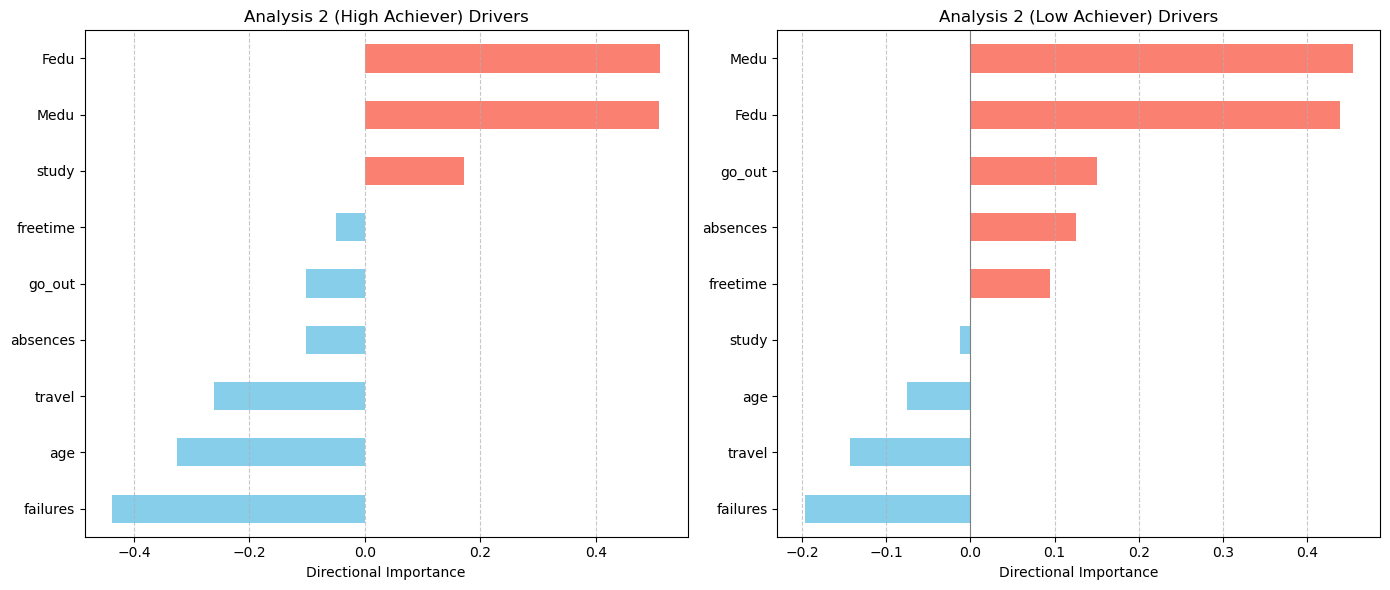

failures   -0.437513
age        -0.325464
travel     -0.261446
absences   -0.101804
go_out     -0.101691
freetime   -0.049716
study       0.171082
Medu        0.509723
Fedu        0.511106
dtype: float64
failures   -0.196715
travel     -0.142756
age        -0.074779
study      -0.012928
freetime    0.094874
absences    0.125145
go_out      0.149787
Fedu        0.439203
Medu        0.453737
dtype: float64


In [10]:

def decision_feature_directional(num=1):

    raw_loadings = pca_hl.components_ 
    restored_importance_h = np.dot(dt_pca_high.feature_importances_, raw_loadings)
    restored_importance_l = np.dot(dt_pca_low.feature_importances_, raw_loadings)

    s_importance_h = pd.Series(restored_importance_h, index=desc.numeric_vars).sort_values()
    s_importance_l = pd.Series(restored_importance_l, index=desc.numeric_vars).sort_values()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    desc.display_title("Directional Impact (Positive: Promotes, Negative: Prevents)", pref='Figure', num=num)

    # colouring the plot
    colors_h = ['skyblue' if x < 0 else 'salmon' for x in s_importance_h]
    colors_l = ['skyblue' if x < 0 else 'salmon' for x in s_importance_l]

    s_importance_h.plot(kind='barh', ax=ax1, color=colors_h)
    ax1.set_title('Analysis 2 (High Achiever) Drivers')
    ax1.set_xlabel('Directional Importance')

    s_importance_l.plot(kind='barh', ax=ax2, color=colors_l)
    ax2.set_title('Analysis 2 (Low Achiever) Drivers')
    ax2.set_xlabel('Directional Importance')

    plt.axvline(0, color='grey', linewidth=0.8)
    [i.grid(axis='x', linestyle='--', alpha=0.7) for i in (ax1, ax2)]
    plt.tight_layout()
    plt.show()

decision_feature_directional(num=1)

raw_loadings = pca_hl.components_ 
restored_importance_h = np.dot(dt_pca_high.feature_importances_, raw_loadings)
restored_importance_l = np.dot(dt_pca_low.feature_importances_, raw_loadings)
s_importance_h = pd.Series(restored_importance_h, index=desc.numeric_vars).sort_values()
s_importance_l = pd.Series(restored_importance_l, index=desc.numeric_vars).sort_values()

print(s_importance_h)
print(s_importance_l)


---
#### Results

---
## Analysis 1
Method      : Classification by ANN  
Data related: Pass/Fail derived from Grade, with two factors by PCA 
Objective   : To build a model to predict pass and fail.

#### Methodology
I conducted classification by ANN with two extracted factors from PCA. The factors are retrieved from all the IVs. The two factors explain about 40% of the variables. The plot below shows how the model predicts the test set's pass and fail.  

#### How to see the graph
The figure visualizes the decision boundary in the 2D latent space defined by PCA.  
Axes: The horizontal axis represents PC1 (the primary latent factor), and the vertical axis represents PC2.  
Colors: The background colors indicate the model's prediction regions (Yellow: Pass, Green: Fail).  
Dots: The black dots represent the test data samples.

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Pass/ Fail Distribution in 2D: PC1 vs PC2 (with test set) (Improved)</span></p><br><br>

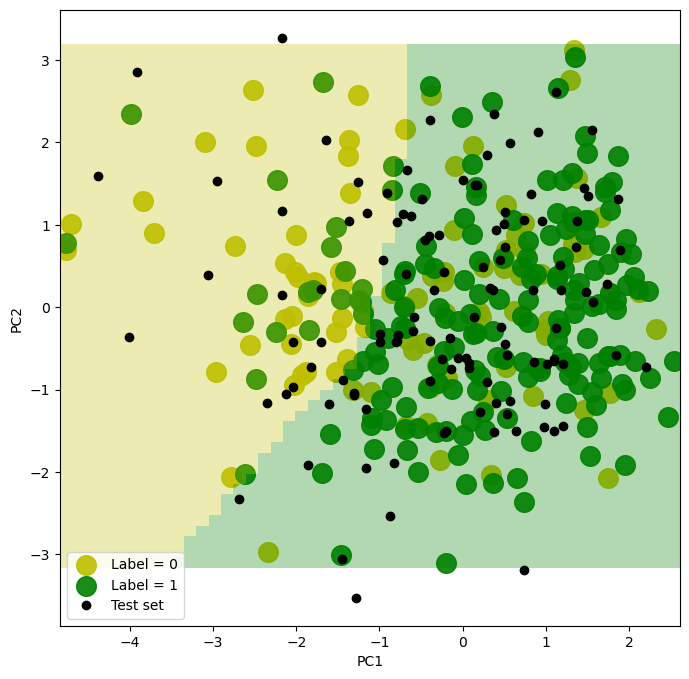

In [11]:
decition_surface_improved(num=1)

#### Key Findings
The visualization reveals that the "Pass" and "Fail" groups form distinct clusters along the PC1 axis. The decision boundary separates these groups, although some overlap remains near the center. The classification accuracy remained comparable after PCA dimensionality reduction(0.697 → 0.697). This suggests that the essence of the variables contributing to the Pass/Fail outcome is successfully captured by the first two principal components. The variables excluded by dimensionality reduction likely contained noise that did not significantly contribute to the classification task.

---
## Analysis 2
Method      : Decision tree  
Data related: Grade, with all IVs  
Objective   : To build a model to discern students with significantly high/ low performance, and search for related variables.

#### Methodology
I constructed separate Decision Tree models for "High Achievers" and "Low Achievers" using the PCA-transformed data. To interpret the PCA results, I restored the feature importance by combining the decision tree's importance scores with the PCA loadings. This method allows us to visualize not only which variables are significant but also the direction of their influence (positive or negative), while effectively handling the high dimensionality of the original data. The positive/negative are verified against the original correlation between grade and the variables. Thereby, consistent interpretation is ensured despite PCA's sign instability.
#### How to read the graph
**Positive value**s indicate factors that **promote** the outcome, and **negative value**s indicate factors that **prevent** it. Factors with values near zero have little to no effect. For example, in the left graph, the Fedu's red long line to the right means it is considered positively related to the high achievers, while the failures' blue long line to the left means its negative relation to them.

<p><span style="font-size: 1.2em;"><b>Figure 2</b>: Directional Impact (Positive: Promotes, Negative: Prevents)</span></p><br><br>

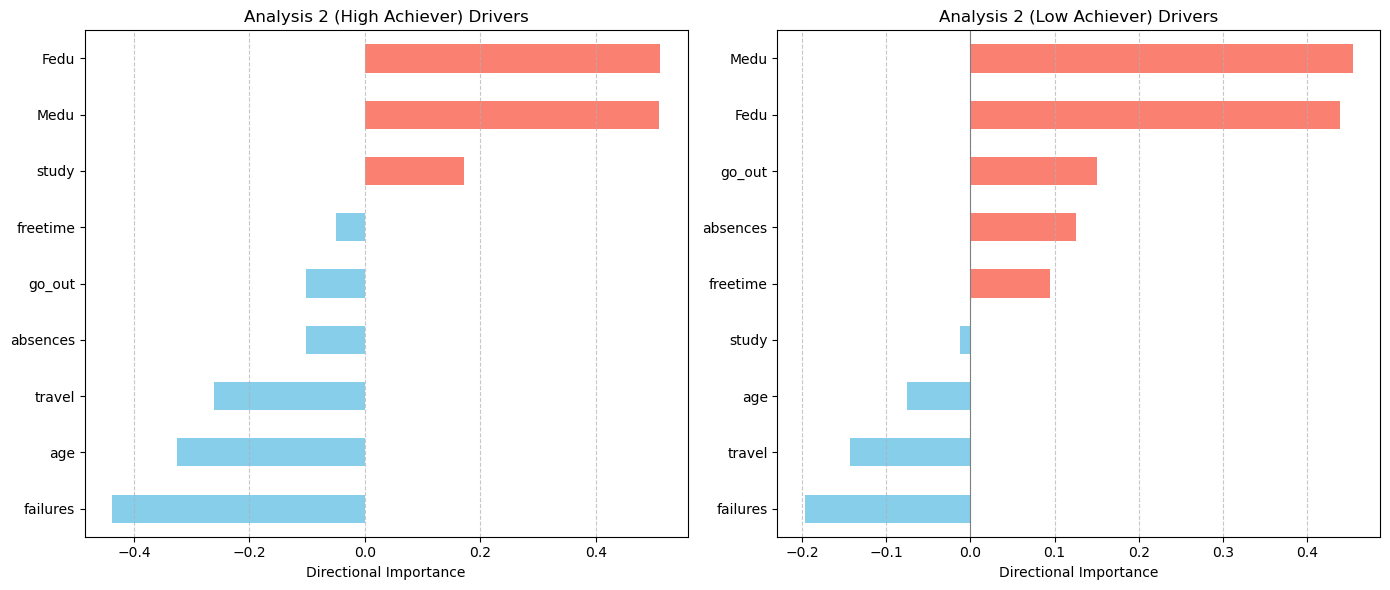

In [12]:
decision_feature_directional(num=2)

#### Key Findings 
Both of the models' accuracy decreased from before the PCA:  
High Model Accuracy: 0.798 → 0.765  
Low Model Accuracy:  0.866 → 0.824  
However, the comparison between them still reveals structural differences from a different perspective as original analysis:   
- For High Achievers: The most significant predictors are Environmental factors (Medu, Fedu) and the absence of past failures (Failures: -0.44). Lifestyle variables like Absences and Go_out have a negative impact, implying discipline is required, but they are not the dominant drivers.
 
- For Low Achievers: Behaviour emerges as a distinct factor. Unlike the High achievers, Absences and Go_out show positive values. This implies that skipping class and socialising (probably excessively) are direct signals for falling into the Low-Achiever category.